In [3]:
import optuna
import logging

# 设置日志级别为WARNING，只显示警告/错误
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 再创建study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2025-11-29 14:37:16,320] A new study created in memory with name: no-name-c82e21d8-c8ba-4d5c-8ff3-8fe4d85e71bb
[I 2025-11-29 14:37:16,394] Trial 0 finished with value: 0.374999463558197 and parameters: {'lr': 0.01242646971495493, 'dropout': 0.5, 'hidden_dim': 16}. Best is trial 0 with value: 0.374999463558197.
[I 2025-11-29 14:37:16,450] Trial 1 finished with value: 0.3414631485939026 and parameters: {'lr': 0.0030764965314895223, 'dropout': 0.2, 'hidden_dim': 16}. Best is trial 0 with value: 0.374999463558197.


数据处理完成！
X_train 形状：torch.Size([138, 3])
y_train 形状：torch.Size([138, 1])


[I 2025-11-29 14:37:16,501] Trial 2 finished with value: 0.0 and parameters: {'lr': 0.027027877996820358, 'dropout': 0.6, 'hidden_dim': 16}. Best is trial 0 with value: 0.374999463558197.
[I 2025-11-29 14:37:16,580] Trial 3 finished with value: 0.42857086658477783 and parameters: {'lr': 0.00260508508188664, 'dropout': 0.30000000000000004, 'hidden_dim': 16}. Best is trial 3 with value: 0.42857086658477783.
[I 2025-11-29 14:37:16,632] Trial 4 finished with value: 0.0 and parameters: {'lr': 0.019626173486836335, 'dropout': 0.4, 'hidden_dim': 16}. Best is trial 3 with value: 0.42857086658477783.
[I 2025-11-29 14:37:16,686] Trial 5 finished with value: 0.0 and parameters: {'lr': 0.013497857864068626, 'dropout': 0.2, 'hidden_dim': 24}. Best is trial 3 with value: 0.42857086658477783.
[I 2025-11-29 14:37:16,789] Trial 6 finished with value: 0.3809519112110138 and parameters: {'lr': 0.00015179198439943412, 'dropout': 0.4, 'hidden_dim': 24}. Best is trial 3 with value: 0.42857086658477783.
[I 2

最佳验证 F1 = 0.533
最佳超参： {'lr': 0.004092814414559982, 'dropout': 0.4, 'hidden_dim': 16}


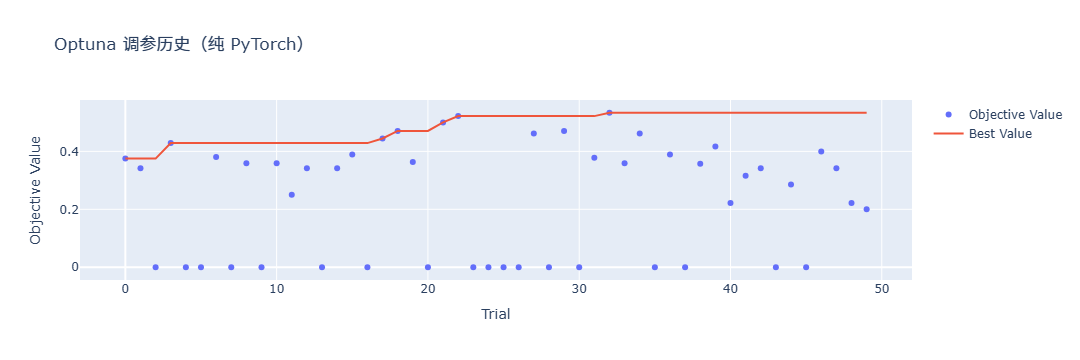

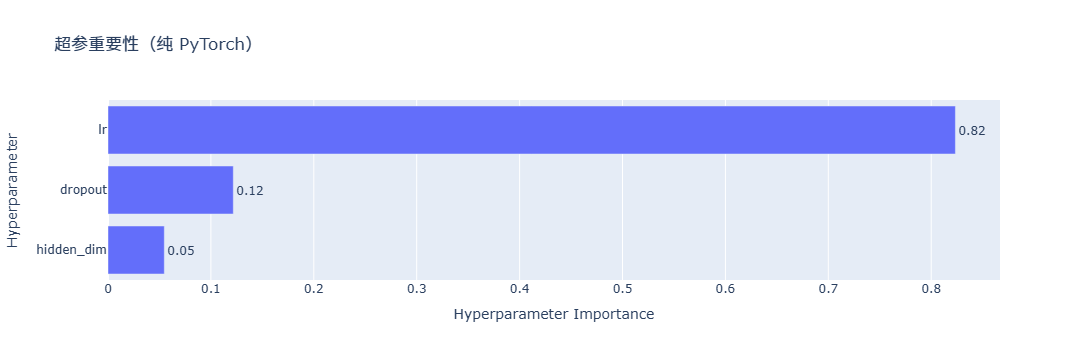

1


In [4]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 1. 数据处理（用pandas直接转tensor，避开NumPy）
df = pd.read_csv(r'E:\miniconda\ChineseSuperLeague\data\features.csv')
X = torch.tensor(df[['home_last3_goals', 'away_last3_concede', 'home_last2_loss']].values, dtype=torch.float32)
y = torch.tensor((df['result'] == 'H').astype(int).values, dtype=torch.float32).unsqueeze(1)

# 手动划分训练测试集（不用sklearn的train_test_split）
n = len(X)
n_test = int(0.2 * n)
indices = torch.randperm(n)
train_indices = indices[:-n_test]
test_indices = indices[-n_test:]

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# 手动标准化（不用StandardScaler）
mean = X_train.mean(dim=0)
std = X_train.std(dim=0)
X_train = (X_train - mean) / (std + 1e-6)
X_test = (X_test - mean) / (std + 1e-6)

print("数据处理完成！")
print(f"X_train 形状：{X_train.shape}")
print(f"y_train 形状：{y_train.shape}")

class MLP_TUNED(nn.Module):
    def __init__(self, hidden_dim=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

# 纯Torch实现F1分数计算
def torch_f1_score(y_true, y_pred):
    y_true = y_true.int()
    y_pred = (y_pred >= 0.5).int()
    
    tp = (y_true * y_pred).sum().float()
    fp = ((1 - y_true) * y_pred).sum().float()
    fn = (y_true * (1 - y_pred)).sum().float()
    
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    return f1.item()

def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.6, step=0.1)
    hidden = trial.suggest_int('hidden_dim', 8, 32, step=8)

    model = MLP_TUNED(hidden_dim=hidden, dropout=dropout)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = 0
    patience = 30
    counter = 0
    
    for epoch in range(300):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()

        # 验证（纯Torch计算，不用NumPy）
        model.eval()
        with torch.no_grad():
            pred_logits = model(X_test)
            pred_prob = torch.sigmoid(pred_logits)
            val_f1 = torch_f1_score(y_test, pred_prob)
            
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            counter = 0
        else:
            counter += 1
        if counter >= patience:
            break
    return best_val_f1

# 运行优化
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f'最佳验证 F1 = {study.best_value:.3f}')
print('最佳超参：', study.best_params)

# 图1：调参历史
import optuna.visualization as vis

fig1 = vis.plot_optimization_history(study)
fig1.update_layout(title='Optuna 调参历史（纯 PyTorch）')
fig1.write_html('figures/optuna_history.html')
fig1.show()

# 图2：超参重要性
fig2 = vis.plot_param_importances(study)
fig2.update_layout(title='超参重要性（纯 PyTorch）')
fig2.write_html('figures/optuna_importance.html')
fig2.show()
print(1)